In [163]:
import pandas as pd, pathlib, numpy as np
from pathlib import Path
import os
from autogluon.tabular import TabularPredictor

# sklearn for baseline
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import roc_auc_score, confusion_matrix

# Plotting
import matplotlib.pyplot as plt
import seaborn as sns


In [164]:
PROJECT_DIR = Path("/Volumes/VIK_SSD/thesis_work/market_shifts")

In [165]:
df = pd.read_parquet("/Volumes/VIK_SSD/thesis_work/market_shifts/data/processed/firms/MODEL/firm_panel_with_zscore.parquet")
# Confirm sizes
df["date"] = pd.to_datetime(df["date"])
df = df.sort_values(["ticker","date"]).reset_index(drop=True)

print("Loaded", len(df), "rows and", len(df.columns), "columns")
print(df.shape)



Loaded 14104 rows and 58 columns
(14104, 58)


In [166]:
# ───────────────────────────────────────────────────────────────────────────
# 1️⃣  Build Ratios + Composite  (run right after df load)
# ───────────────────────────────────────────────────────────────────────────
import numpy as np
from sklearn.preprocessing import StandardScaler

def safe_div(num, den):
    """Elementwise divide, returns NaN where denominator is 0 or NaN."""
    return num.where((den != 0) & den.notna()) / den

# --- Create ratio columns --------------------------------------------------
ratio_formulas = {
    "debt_to_assets":      lambda d: safe_div(d["total_liabilities"], d["total_assets"]),
    "equity_multiplier":   lambda d: safe_div(d["total_assets"], d["total_equity"]),
    "asset_turnover":      lambda d: safe_div(d["total_revenue"], d["total_assets"]),
    "inventory_turnover":  lambda d: safe_div(d["cost_of_revenue"], d["inventory"]),
    "r_and_d_intensity":   lambda d: safe_div(d["r_and_d_expense"], d["total_revenue"]),
    "cash_per_share":      lambda d: safe_div(d["cash_equivalents"], d["shares_outstanding"]),
}

for col, func in ratio_formulas.items():
    if col not in df.columns:          # Avoid recompute if exists
        df[col] = func(df)

# --- Replace infinities & clip --------------------------------------------
ratio_cols = list(ratio_formulas.keys())
df[ratio_cols] = df[ratio_cols].replace([np.inf, -np.inf], np.nan)
df[ratio_cols] = df[ratio_cols].clip(lower=-1e6, upper=1e6)

# --- Fill NaNs with 0 for z-scoring ---------------------------------------
df[ratio_cols] = df[ratio_cols].fillna(0)

# --- Compute z-score composite --------------------------------------------
scaler = StandardScaler()
Z = scaler.fit_transform(df[ratio_cols])
z_cols = [f"{c}_z" for c in ratio_cols]
df[z_cols] = Z
df["zscore_composite"] = df[z_cols].sum(axis=1)

print("✅ Ratios & zscore_composite added.")
print(df[ratio_cols + ["zscore_composite"]].head().T)


✅ Ratios & zscore_composite added.
                            0           1          2          3          4
debt_to_assets       0.468564    0.523636   0.336721   0.310374   0.333936
equity_multiplier    1.881693    2.099236   1.507660   1.450061   1.501357
asset_turnover       0.000000    0.000000   0.000000   0.000000   0.000000
inventory_turnover   0.000000    0.000000   0.000000   0.000000   0.000000
r_and_d_intensity    0.000000    0.000000   0.000000   0.000000   0.000000
cash_per_share      10.527667 -575.981920  13.102983  13.054675  12.999704
zscore_composite     0.003068   -0.009159   0.002725   0.002660   0.002716


In [167]:
# Explicit macro list (use whichever exist)
macro_features = ["FEDFUNDS","GS10","INDPRO","M2SL","UNRATE","VIXCLS","NFCI","GDPC1","BAMLH0A0HYM2","USEPUINDXD"]
macro_features = [c for c in macro_features if c in df.columns]

ratio_features = list(ratio_formulas.keys()) + ["zscore_composite"]

features = [c for c in ratio_features + macro_features if c in df.columns]
print(f"Using {len(features)} features:\n", features)


Using 17 features:
 ['debt_to_assets', 'equity_multiplier', 'asset_turnover', 'inventory_turnover', 'r_and_d_intensity', 'cash_per_share', 'zscore_composite', 'FEDFUNDS', 'GS10', 'INDPRO', 'M2SL', 'UNRATE', 'VIXCLS', 'NFCI', 'GDPC1', 'BAMLH0A0HYM2', 'USEPUINDXD']


In [168]:
# ─── Add "normal" raw financials ─────────────────────────────────────
normal_cols = [
    "cash_equivalents","cash_flow_financing","cash_flow_investing","cash_flow_operating",
    "current_assets","current_liabilities","eps_basic","eps_diluted","total_assets",
    "total_equity","total_liabilities","retained_earnings"
]
# Only keep columns that actually exist in df
normal_cols = [c for c in normal_cols if c in df.columns]

# Optionally: filter out columns with very low coverage (<30%)
normal_cols = [c for c in normal_cols if df[c].isna().mean() < 0.3]

# Update features
features = list(dict.fromkeys(features + normal_cols))  # preserves order, drops dups
print(f"Using {len(features)} features:\n", features)


Using 29 features:
 ['debt_to_assets', 'equity_multiplier', 'asset_turnover', 'inventory_turnover', 'r_and_d_intensity', 'cash_per_share', 'zscore_composite', 'FEDFUNDS', 'GS10', 'INDPRO', 'M2SL', 'UNRATE', 'VIXCLS', 'NFCI', 'GDPC1', 'BAMLH0A0HYM2', 'USEPUINDXD', 'cash_equivalents', 'cash_flow_financing', 'cash_flow_investing', 'cash_flow_operating', 'current_assets', 'current_liabilities', 'eps_basic', 'eps_diluted', 'total_assets', 'total_equity', 'total_liabilities', 'retained_earnings']


In [169]:
# Define rolling streak targets BEFORE split!
def rolling_streak(series, positive=True, window=4):
    flag = (series > 0) if positive else (series < 0)
    return (flag.rolling(window, min_periods=window).sum() == window).astype(int)

# Compute on full df!
df = df.sort_values(["ticker","date"]).reset_index(drop=True)
df["success_net4"] = df.groupby("ticker")["net_income"].transform(lambda s: rolling_streak(s, True))
df["success_margin4"] = df.groupby("ticker")["net_margin"].transform(lambda s: rolling_streak(s, True))
df["distress_net4"] = df.groupby("ticker")["net_income"].transform(lambda s: rolling_streak(s, False))

print("Binary targets now exist:", [c for c in df.columns if c.endswith("net4") or c.endswith("margin4")])
print(df[["success_net4","success_margin4","distress_net4"]].sum())


Binary targets now exist: ['success_net4', 'success_margin4', 'distress_net4']
success_net4       5124
success_margin4    2628
distress_net4       190
dtype: int64


In [170]:
# ─── Top/bottom quartile success metrics ─────────────────────────────
# Use e.g. net_margin (or zscore_composite, or net_income) as you prefer
metric = "net_margin"
thresh_hi = df[metric].quantile(0.75)
thresh_lo = df[metric].quantile(0.25)
df["top_quartile_success"] = (df[metric] >= thresh_hi).astype(int)
df["bottom_quartile_distress"] = (df[metric] <= thresh_lo).astype(int)

print(f"Top quartile threshold: {thresh_hi:.4f}")
print(f"Bottom quartile threshold: {thresh_lo:.4f}")
print(df[["top_quartile_success", "bottom_quartile_distress"]].sum())

print("Binary targets now exist:", [c for c in df.columns if c.endswith("success") or c.endswith("distress")])

Top quartile threshold: 0.2430
Bottom quartile threshold: 0.0214
top_quartile_success        1670
bottom_quartile_distress    1670
dtype: int64
Binary targets now exist: ['top_quartile_success', 'bottom_quartile_distress']


In [171]:
# ─── 4Q rolling average net income ───────────────────────────────────
df = df.sort_values(["ticker", "date"])
df["net_income_ma4"] = (
    df.groupby("ticker")["net_income"]
    .transform(lambda s: s.rolling(4, min_periods=4).mean())
)

# Classification: define a threshold for "success" (e.g. >0)
df["net_income_ma4_success"] = (df["net_income_ma4"] > 0.65).astype(int)
print(df[["net_income_ma4", "net_income_ma4_success"]].describe())

       net_income_ma4  net_income_ma4_success
count    1.159200e+04            14104.000000
mean     1.012700e+09                0.717102
std      2.493882e+09                0.450423
min     -2.334675e+10                0.000000
25%      1.074834e+08                0.000000
50%      4.073750e+08                1.000000
75%      1.121712e+09                1.000000
max      4.549925e+10                1.000000


In [172]:
train_df = df.sample(frac=0.8, random_state=42)
test_df  = df.drop(train_df.index)
print(train_df.shape, test_df.shape)


(11283, 72) (2821, 72)


In [173]:
print("success_net4 in train?", "success_net4" in train_df.columns)
print("success_net4 in test?",  "success_net4" in test_df.columns)
print("net_income_ma4 in train?", "net_income_ma4" in train_df.columns)
print("net_income_ma4 in test?",  "net_income_ma4" in test_df.columns)
print("top_quartile_success in train?", "top_quartile_success" in train_df.columns)
print("net_income_ma4 in test?",  "net_income_ma4" in test_df.columns)



success_net4 in train? True
success_net4 in test? True
net_income_ma4 in train? True
net_income_ma4 in test? True
top_quartile_success in train? True
net_income_ma4 in test? True


In [174]:
df["success_net4"].value_counts(normalize=True)
df["net_income_ma4"].value_counts(normalize=True)


net_income_ma4
2.785000e+08    0.000604
5.027500e+08    0.000518
5.835000e+08    0.000518
2.133810e+08    0.000518
1.068500e+09    0.000518
                  ...   
4.113728e+08    0.000086
5.752878e+08    0.000086
7.333492e+08    0.000086
7.992650e+08    0.000086
4.267500e+08    0.000086
Name: proportion, Length: 9588, dtype: float64

1st MODEL

In [175]:
output_dir = "/Volumes/VIK_SSD/thesis_work/market_shifts/data/processed/firms/MODEL/logs/"
target = "top_quartile_success"  # or "success_net4", "net_income_ma4_success", etc.
predictor = TabularPredictor(label=target, eval_metric="roc_auc",
                             path=output_dir,   # <- all outputs/logs go here
    verbosity=2).fit(
    train_df[features + [target]],
    time_limit=600, presets=["medium_quality"],
)
predictor.evaluate(test_df[features + [target]], silent=True)

Verbosity: 2 (Standard Logging)
=================== System Info ===================
AutoGluon Version:  1.3.0
Python Version:     3.12.9
Operating System:   Darwin
Platform Machine:   arm64
Platform Version:   Darwin Kernel Version 24.1.0: Thu Oct 10 21:05:14 PDT 2024; root:xnu-11215.41.3~2/RELEASE_ARM64_T8103
CPU Count:          8
Memory Avail:       4.39 GB / 16.00 GB (27.4%)
Disk Space Avail:   39.77 GB / 476.92 GB (8.3%)
Presets specified: ['medium_quality']
Beginning AutoGluon training ... Time limit = 600s
AutoGluon will save models to "/Volumes/VIK_SSD/thesis_work/market_shifts/data/processed/firms/MODEL/logs"
Train Data Rows:    11283
Train Data Columns: 29
Label Column:       top_quartile_success
AutoGluon infers your prediction problem is: 'binary' (because only two unique label-values observed).
	2 unique label values:  [np.int64(1), np.int64(0)]
	If 'binary' is not the correct problem_type, please manually specify the problem_type parameter during Predictor init (You may sp

{'roc_auc': np.float64(0.9582049669193438),
 'accuracy': 0.9305210918114144,
 'balanced_accuracy': np.float64(0.755153213254301),
 'mcc': np.float64(0.6418440013825536),
 'f1': 0.6524822695035462,
 'precision': 0.8720379146919431,
 'recall': 0.5212464589235127}

These features in provided data are not utilized by the predictor and will be ignored: ['ticker', 'shortname', 'Sector', 'Industry', 'Fulltimeemployees', 'Weight', 'date', 'accounts_receivable', 'capex', 'depreciation_amortization', 'inventory', 'liabilities_plus_equity', 'net_income', 'operating_income', 'ppe_net', 'r_and_d_expense', 'shares_outstanding', 'total_revenue', 'wavg_shares_basic', 'cost_of_revenue', 'gross_margin', 'operating_margin', 'net_margin', 'price', 'Z_WC_TA', 'Z_RE_TA', 'Z_EBIT_TA', 'Z_MVE_TL', 'Z_SALES_TA', 'altman_z', 'debt_to_assets_z', 'equity_multiplier_z', 'asset_turnover_z', 'inventory_turnover_z', 'r_and_d_intensity_z', 'cash_per_share_z', 'success_net4', 'success_margin4', 'distress_net4', 'bottom_quartile_distress', 'net_income_ma4', 'net_income_ma4_success']
Computing feature importance via permutation shuffling for 29 features using 2821 rows with 5 shuffle sets...
	27.36s	= Expected runtime (5.47s per shuffle set)
	8.16s	= Actual runtime (Completed 5 

                     importance    stddev       p_value
asset_turnover         0.279119  0.009641  1.705045e-07
total_assets           0.023144  0.001549  2.394056e-06
eps_basic              0.014488  0.001342  8.724679e-06
current_assets         0.009150  0.002037  2.760356e-04
current_liabilities    0.006926  0.000878  3.033809e-05
eps_diluted            0.006870  0.001516  2.671372e-04
zscore_composite       0.005918  0.000650  1.721678e-05
total_liabilities      0.005419  0.001038  1.537468e-04
r_and_d_intensity      0.004868  0.000689  4.688529e-05
retained_earnings      0.004420  0.000333  3.850691e-06
cash_equivalents       0.003326  0.000850  4.700639e-04
total_equity           0.003189  0.000385  2.489778e-05
cash_flow_operating    0.003061  0.000877  7.286692e-04
equity_multiplier      0.001985  0.000430  2.486950e-04
debt_to_assets         0.001896  0.000702  1.895638e-03
cash_per_share         0.001812  0.000358  1.747976e-04
cash_flow_financing    0.001675  0.000329  1.699

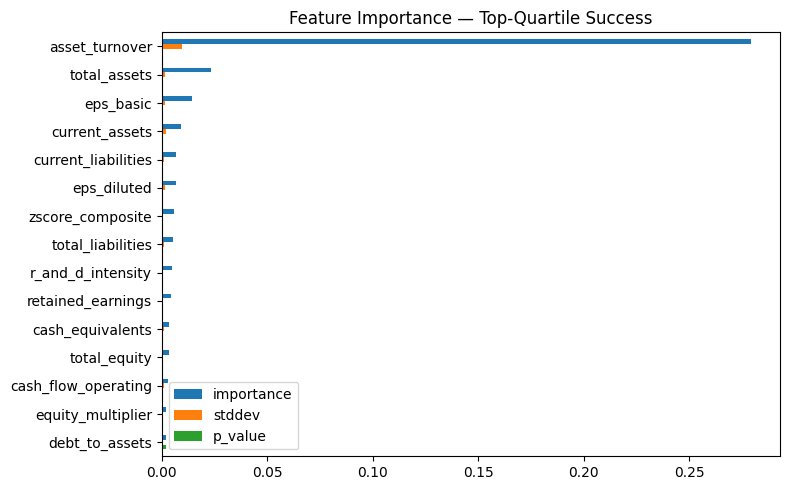

In [176]:
fi = predictor.feature_importance(test_df)
fi = fi.drop(columns=["n","p99_high","p99_low"])
print(fi.head(20))
fi.head(15).plot.barh(figsize=(8, 5), title="Feature Importance")
plt.gca().invert_yaxis()               # optional: keep most-important at top
plt.title("Feature Importance — Top-Quartile Success")
plt.tight_layout()
plt.show()




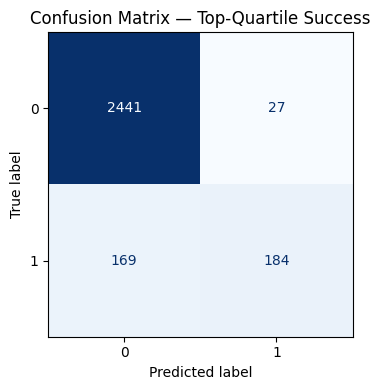

In [177]:
# ─── Confusion Matrix ────────────────────────────────────────────────
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

y_pred = predictor.predict(test_df[features])
cm = confusion_matrix(y_true, y_pred, labels=predictor.class_labels)
disp = ConfusionMatrixDisplay(cm, display_labels=predictor.class_labels)
fig, ax = plt.subplots(figsize=(4,4))
disp.plot(ax=ax, cmap="Blues", colorbar=False)
plt.title("Confusion Matrix — Top-Quartile Success")
plt.tight_layout()

plt.show()


Saved ROC curve to /Volumes/VIK_SSD/thesis_work/market_shifts/data/processed/firms/MODEL/logs/roc_curve.png


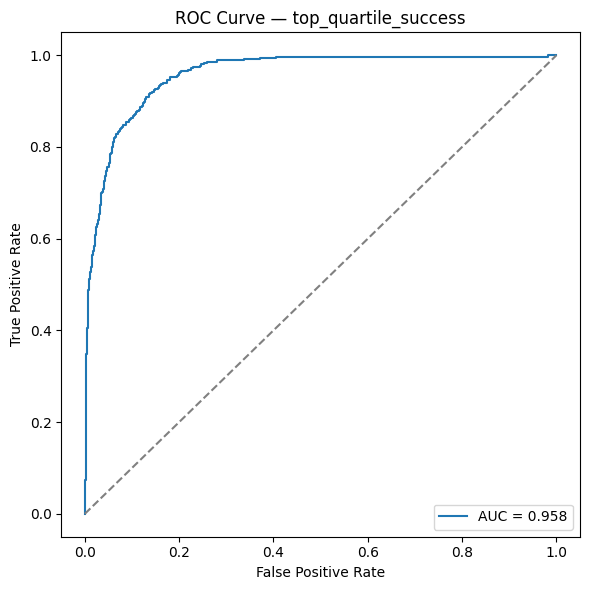

In [178]:
# ─── Robust ROC Curve Cell ───────────────────────────────────────────────
from sklearn.metrics import roc_curve, auc
import matplotlib.pyplot as plt

# 1) Get predicted probabilities as a pandas DataFrame
proba = predictor.predict_proba(test_df[features], as_pandas=True)

# 2) Identify the positive‐class label (usually 1)
#    AutoGluon stores classes in predictor.class_labels
pos_label = predictor.class_labels[1] if len(predictor.class_labels) > 1 else predictor.class_labels[0]

# 3) Extract the column for that label
if isinstance(proba, pd.DataFrame):
    y_prob = proba[pos_label]
else:
    # fallback if numpy array
    y_prob = proba[:, 1]

# 4) True labels
y_true = test_df[target].values

# 5) Compute ROC
fpr, tpr, _ = roc_curve(y_true, y_prob)
roc_auc = auc(fpr, tpr)

# 6) Plot
plt.figure(figsize=(6,6))
plt.plot(fpr, tpr, label=f"AUC = {roc_auc:.3f}")
plt.plot([0,1], [0,1], "--", color="gray")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title(f"ROC Curve — {target}")
plt.legend(loc="lower right")
plt.tight_layout()

# 7) Save
out_fp = Path(predictor.path) / "roc_curve.png"
plt.savefig(out_fp, dpi=150)
print(f"Saved ROC curve to {out_fp}")

# 8) Display
plt.show()


2ND MODEL

In [180]:
output_dir = "/Volumes/VIK_SSD/thesis_work/market_shifts/data/processed/firms/MODEL/logs/"
target = "success_net4"  # or any target you want!
predictor2 = TabularPredictor(
    label=target,
    eval_metric="roc_auc",  # or "rmse" for regression
    path=output_dir,
    verbosity=2
).fit(
    train_df[features + [target]],
    time_limit=600,
    presets=["medium_quality"]  # or "good_quality_faster_train", etc.
)
predictor2.evaluate(test_df[features + [target]], silent=True)

Verbosity: 2 (Standard Logging)
=================== System Info ===================
AutoGluon Version:  1.3.0
Python Version:     3.12.9
Operating System:   Darwin
Platform Machine:   arm64
Platform Version:   Darwin Kernel Version 24.1.0: Thu Oct 10 21:05:14 PDT 2024; root:xnu-11215.41.3~2/RELEASE_ARM64_T8103
CPU Count:          8
Memory Avail:       4.33 GB / 16.00 GB (27.0%)
Disk Space Avail:   39.97 GB / 476.92 GB (8.4%)
Presets specified: ['medium_quality']
Beginning AutoGluon training ... Time limit = 600s
AutoGluon will save models to "/Volumes/VIK_SSD/thesis_work/market_shifts/data/processed/firms/MODEL/logs"
Train Data Rows:    11283
Train Data Columns: 29
Label Column:       success_net4
AutoGluon infers your prediction problem is: 'binary' (because only two unique label-values observed).
	2 unique label values:  [np.int64(1), np.int64(0)]
	If 'binary' is not the correct problem_type, please manually specify the problem_type parameter during Predictor init (You may specify pr

[1000]	valid_set's binary_logloss: 0.43658
[2000]	valid_set's binary_logloss: 0.417144
[3000]	valid_set's binary_logloss: 0.416153


	0.8862	 = Validation score   (roc_auc)
	5.98s	 = Training   runtime
	0.05s	 = Validation runtime
Fitting model: LightGBM ... Training model for up to 593.71s of the 593.71s of remaining time.


[1000]	valid_set's binary_logloss: 0.404874
[2000]	valid_set's binary_logloss: 0.396872


	0.9013	 = Validation score   (roc_auc)
	4.49s	 = Training   runtime
	0.03s	 = Validation runtime
Fitting model: RandomForestGini ... Training model for up to 589.11s of the 589.11s of remaining time.
	0.895	 = Validation score   (roc_auc)
	1.74s	 = Training   runtime
	0.03s	 = Validation runtime
Fitting model: RandomForestEntr ... Training model for up to 586.87s of the 586.87s of remaining time.
	0.8944	 = Validation score   (roc_auc)
	2.25s	 = Training   runtime
	0.03s	 = Validation runtime
Fitting model: CatBoost ... Training model for up to 584.14s of the 584.14s of remaining time.
	0.8882	 = Validation score   (roc_auc)
	20.59s	 = Training   runtime
	0.0s	 = Validation runtime
Fitting model: ExtraTreesGini ... Training model for up to 563.51s of the 563.51s of remaining time.
	0.7414	 = Validation score   (roc_auc)
	0.62s	 = Training   runtime
	0.04s	 = Validation runtime
Fitting model: ExtraTreesEntr ... Training model for up to 561.91s of the 561.91s of remaining time.
	0.75	 =

[1000]	valid_set's binary_logloss: 0.392484


	0.9043	 = Validation score   (roc_auc)
	15.03s	 = Training   runtime
	0.03s	 = Validation runtime
Fitting model: WeightedEnsemble_L2 ... Training model for up to 360.00s of the 425.68s of remaining time.
	Ensemble Weights: {'KNeighborsDist': 0.278, 'LightGBMLarge': 0.278, 'RandomForestGini': 0.222, 'LightGBM': 0.111, 'RandomForestEntr': 0.056, 'NeuralNetTorch': 0.056}
	0.9236	 = Validation score   (roc_auc)
	0.05s	 = Training   runtime
	0.0s	 = Validation runtime
AutoGluon training complete, total runtime = 174.42s ... Best model: WeightedEnsemble_L2 | Estimated inference throughput: 8494.3 rows/s (1129 batch size)
TabularPredictor saved. To load, use: predictor = TabularPredictor.load("/Volumes/VIK_SSD/thesis_work/market_shifts/data/processed/firms/MODEL/logs")


{'roc_auc': np.float64(0.915798530007163),
 'accuracy': 0.8380007089684509,
 'balanced_accuracy': np.float64(0.7997095829829644),
 'mcc': np.float64(0.6321350602742444),
 'f1': 0.7422447828539199,
 'precision': 0.8225,
 'recall': 0.6762589928057554}

These features in provided data are not utilized by the predictor and will be ignored: ['ticker', 'shortname', 'Sector', 'Industry', 'Fulltimeemployees', 'Weight', 'date', 'accounts_receivable', 'capex', 'depreciation_amortization', 'inventory', 'liabilities_plus_equity', 'net_income', 'operating_income', 'ppe_net', 'r_and_d_expense', 'shares_outstanding', 'total_revenue', 'wavg_shares_basic', 'cost_of_revenue', 'gross_margin', 'operating_margin', 'net_margin', 'price', 'Z_WC_TA', 'Z_RE_TA', 'Z_EBIT_TA', 'Z_MVE_TL', 'Z_SALES_TA', 'altman_z', 'debt_to_assets_z', 'equity_multiplier_z', 'asset_turnover_z', 'inventory_turnover_z', 'r_and_d_intensity_z', 'cash_per_share_z', 'success_net4', 'success_margin4', 'distress_net4', 'bottom_quartile_distress', 'net_income_ma4', 'net_income_ma4_success']
Computing feature importance via permutation shuffling for 29 features using 2821 rows with 5 shuffle sets...
	80.85s	= Expected runtime (16.17s per shuffle set)
	34.84s	= Actual runtime (Completed 

                     importance    stddev   p_value
total_assets           0.025436  0.006230  0.000399
total_equity           0.021863  0.006287  0.000737
retained_earnings      0.014744  0.005364  0.001777
cash_equivalents       0.012232  0.004076  0.001284
M2SL                   0.008310  0.002328  0.000668
zscore_composite       0.006306  0.001446  0.000310
equity_multiplier      0.005915  0.001030  0.000106
cash_flow_investing    0.005859  0.005005  0.029481
current_assets         0.004202  0.002988  0.017339
INDPRO                 0.003463  0.000965  0.000654
cash_flow_operating    0.002596  0.004173  0.118323
eps_basic              0.002267  0.003188  0.093561
asset_turnover         0.001882  0.001224  0.013153
inventory_turnover     0.001403  0.000622  0.003628
GDPC1                  0.001275  0.000785  0.011066
UNRATE                 0.001129  0.001223  0.053946
debt_to_assets         0.001063  0.001962  0.146185
total_liabilities      0.000662  0.005935  0.407652
NFCI        

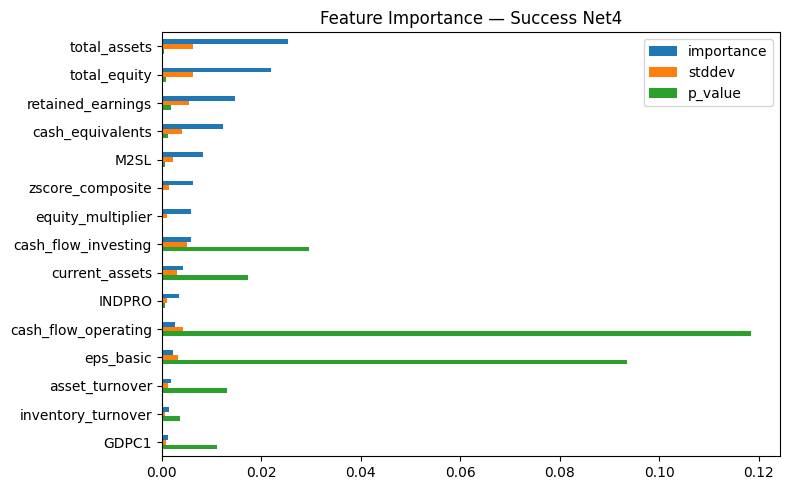

In [181]:
fi = predictor.feature_importance(test_df)
fi = fi.drop(columns=["n","p99_high","p99_low"])
print(fi.head(20))
fi.head(15).plot.barh(figsize=(8, 5), title="Feature Importance")
plt.gca().invert_yaxis()               # optional: keep most-important at top
plt.title("Feature Importance — Success Net4")
plt.tight_layout()
plt.show()

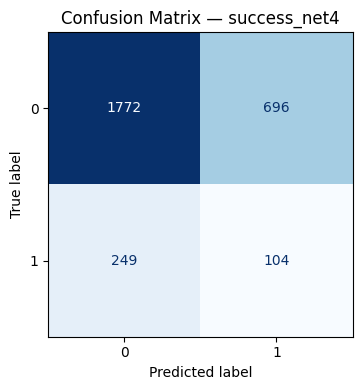

In [182]:
# ─── Confusion Matrix ────────────────────────────────────────────────
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

y_pred = predictor.predict(test_df[features])
cm = confusion_matrix(y_true, y_pred, labels=predictor2.class_labels)
disp = ConfusionMatrixDisplay(cm, display_labels=predictor2.class_labels)
fig, ax = plt.subplots(figsize=(4,4))
disp.plot(ax=ax, cmap="Blues", colorbar=False)
plt.title("Confusion Matrix — success_net4")
plt.tight_layout()

plt.show()


Saved ROC curve to /Volumes/VIK_SSD/thesis_work/market_shifts/data/processed/firms/MODEL/logs/roc_curve.png


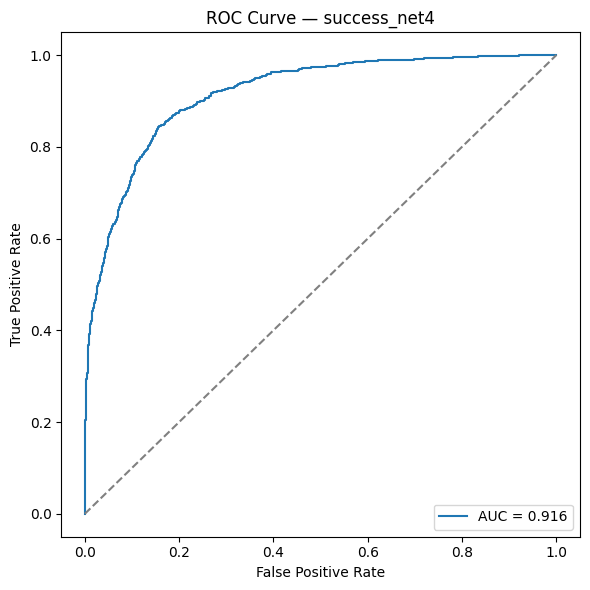

In [183]:
# ─── Robust ROC Curve Cell ───────────────────────────────────────────────
from sklearn.metrics import roc_curve, auc
import matplotlib.pyplot as plt

# 1) Get predicted probabilities as a pandas DataFrame
proba = predictor2.predict_proba(test_df[features], as_pandas=True)

# 2) Identify the positive‐class label (usually 1)
#    AutoGluon stores classes in predictor.class_labels
pos_label = predictor2.class_labels[1] if len(predictor2.class_labels) > 1 else predictor2.class_labels[0]

# 3) Extract the column for that label
if isinstance(proba, pd.DataFrame):
    y_prob = proba[pos_label]
else:
    # fallback if numpy array
    y_prob = proba[:, 1]

# 4) True labels
y_true = test_df[target].values

# 5) Compute ROC
fpr, tpr, _ = roc_curve(y_true, y_prob)
roc_auc = auc(fpr, tpr)

# 6) Plot
plt.figure(figsize=(6,6))
plt.plot(fpr, tpr, label=f"AUC = {roc_auc:.3f}")
plt.plot([0,1], [0,1], "--", color="gray")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title(f"ROC Curve — {target}")
plt.legend(loc="lower right")
plt.tight_layout()

# 7) Save
out_fp = Path(predictor2.path) / "roc_curve.png"
plt.savefig(out_fp, dpi=150)
print(f"Saved ROC curve to {out_fp}")

# 8) Display
plt.show()


3RD MODEL

In [185]:

target = "distress_net4"  # or any target you want!
predictor3 = TabularPredictor(
    label=target,
    eval_metric="roc_auc",  # or "rmse" for regression
    path=output_dir,
    verbosity=2
).fit(
    train_df[features + [target]],
    time_limit=600,
    presets=["medium_quality"]  # or "good_quality_faster_train", etc.
)
predictor3.evaluate(test_df[features + [target]], silent=True)

Verbosity: 2 (Standard Logging)
=================== System Info ===================
AutoGluon Version:  1.3.0
Python Version:     3.12.9
Operating System:   Darwin
Platform Machine:   arm64
Platform Version:   Darwin Kernel Version 24.1.0: Thu Oct 10 21:05:14 PDT 2024; root:xnu-11215.41.3~2/RELEASE_ARM64_T8103
CPU Count:          8
Memory Avail:       4.46 GB / 16.00 GB (27.9%)
Disk Space Avail:   39.76 GB / 476.92 GB (8.3%)
Presets specified: ['medium_quality']
Beginning AutoGluon training ... Time limit = 600s
AutoGluon will save models to "/Volumes/VIK_SSD/thesis_work/market_shifts/data/processed/firms/MODEL/logs"
Train Data Rows:    11283
Train Data Columns: 29
Label Column:       distress_net4
AutoGluon infers your prediction problem is: 'binary' (because only two unique label-values observed).
	2 unique label values:  [np.int64(0), np.int64(1)]
	If 'binary' is not the correct problem_type, please manually specify the problem_type parameter during Predictor init (You may specify p

{'roc_auc': np.float64(0.9624411369782704),
 'accuracy': 0.9904289259127969,
 'balanced_accuracy': np.float64(0.657715074607107),
 'mcc': np.float64(0.5368851292898605),
 'f1': 0.47058823529411764,
 'precision': 0.9230769230769231,
 'recall': 0.3157894736842105}

These features in provided data are not utilized by the predictor and will be ignored: ['ticker', 'shortname', 'Sector', 'Industry', 'Fulltimeemployees', 'Weight', 'date', 'accounts_receivable', 'capex', 'depreciation_amortization', 'inventory', 'liabilities_plus_equity', 'net_income', 'operating_income', 'ppe_net', 'r_and_d_expense', 'shares_outstanding', 'total_revenue', 'wavg_shares_basic', 'cost_of_revenue', 'gross_margin', 'operating_margin', 'net_margin', 'price', 'Z_WC_TA', 'Z_RE_TA', 'Z_EBIT_TA', 'Z_MVE_TL', 'Z_SALES_TA', 'altman_z', 'debt_to_assets_z', 'equity_multiplier_z', 'asset_turnover_z', 'inventory_turnover_z', 'r_and_d_intensity_z', 'cash_per_share_z', 'success_net4', 'success_margin4', 'distress_net4', 'bottom_quartile_distress', 'net_income_ma4', 'net_income_ma4_success']
Computing feature importance via permutation shuffling for 29 features using 2821 rows with 5 shuffle sets...
	33.2s	= Expected runtime (6.64s per shuffle set)
	7.57s	= Actual runtime (Completed 5 o

                       importance    stddev   p_value
eps_diluted          1.435244e-02  0.008820  0.010995
eps_basic            8.487335e-03  0.007211  0.029037
BAMLH0A0HYM2         7.060918e-03  0.001872  0.000542
GS10                 6.562872e-03  0.002508  0.002127
cash_flow_operating  6.366592e-03  0.005345  0.028093
retained_earnings    3.981616e-03  0.005772  0.098924
FEDFUNDS             3.660566e-03  0.002628  0.017855
NFCI                 3.598009e-03  0.004147  0.062198
current_liabilities  3.531320e-03  0.006446  0.143906
USEPUINDXD           2.022603e-03  0.002230  0.056208
total_liabilities    1.903687e-03  0.006825  0.283322
VIXCLS               1.889110e-03  0.007269  0.296174
r_and_d_intensity    1.713491e-03  0.004775  0.233658
cash_flow_investing  1.673890e-03  0.002098  0.074481
asset_turnover       8.474479e-04  0.005172  0.366326
cash_flow_financing  7.350747e-04  0.002490  0.272653
equity_multiplier    5.927429e-04  0.003414  0.358800
UNRATE              -5.73918

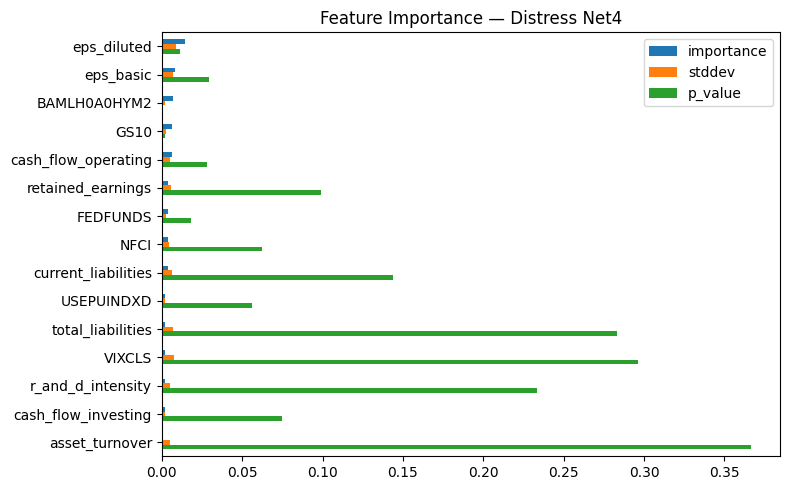

In [186]:
fi = predictor.feature_importance(test_df)
fi = fi.drop(columns=["n","p99_high","p99_low"])
print(fi.head(20))
fi.head(15).plot.barh(figsize=(8, 5), title="Feature Importance")
plt.gca().invert_yaxis()               # optional: keep most-important at top
plt.title("Feature Importance — Distress Net4")
plt.tight_layout()
plt.show()


Saved ROC curve to /Volumes/VIK_SSD/thesis_work/market_shifts/data/processed/firms/MODEL/logs/roc_curve.png


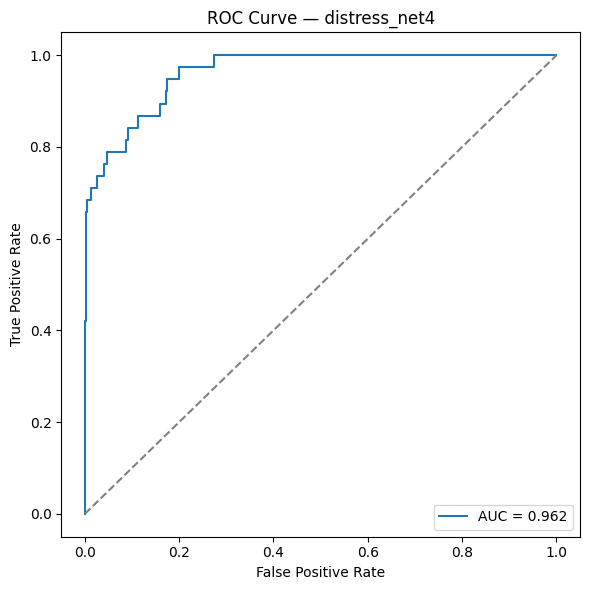

In [187]:
# ─── Robust ROC Curve Cell ───────────────────────────────────────────────
from sklearn.metrics import roc_curve, auc
import matplotlib.pyplot as plt

# 1) Get predicted probabilities as a pandas DataFrame
proba = predictor2.predict_proba(test_df[features], as_pandas=True)

# 2) Identify the positive‐class label (usually 1)
#    AutoGluon stores classes in predictor.class_labels
pos_label = predictor2.class_labels[1] if len(predictor2.class_labels) > 1 else predictor2.class_labels[0]

# 3) Extract the column for that label
if isinstance(proba, pd.DataFrame):
    y_prob = proba[pos_label]
else:
    # fallback if numpy array
    y_prob = proba[:, 1]

# 4) True labels
y_true = test_df[target].values

# 5) Compute ROC
fpr, tpr, _ = roc_curve(y_true, y_prob)
roc_auc = auc(fpr, tpr)

# 6) Plot
plt.figure(figsize=(6,6))
plt.plot(fpr, tpr, label=f"AUC = {roc_auc:.3f}")
plt.plot([0,1], [0,1], "--", color="gray")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title(f"ROC Curve — {target}")
plt.legend(loc="lower right")
plt.tight_layout()

# 7) Save
out_fp = Path(predictor3.path) / "roc_curve.png"
plt.savefig(out_fp, dpi=150)
print(f"Saved ROC curve to {out_fp}")

# 8) Display
plt.show()


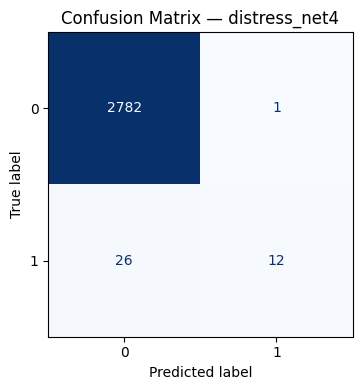

In [188]:
# ─── Confusion Matrix ────────────────────────────────────────────────
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

y_pred = predictor3.predict(test_df[features])
cm = confusion_matrix(y_true, y_pred, labels=predictor3.class_labels)
disp = ConfusionMatrixDisplay(cm, display_labels=predictor3.class_labels)
fig, ax = plt.subplots(figsize=(4,4))
disp.plot(ax=ax, cmap="Blues", colorbar=False)
plt.title("Confusion Matrix — distress_net4")
plt.tight_layout()

plt.show()


4Th MODEL


In [189]:

output_dir = "/Volumes/VIK_SSD/thesis_work/market_shifts/data/processed/firms/MODEL/logs/"
target = "net_income_ma4_success"  # or any target you want!
predictor4 = TabularPredictor(
    label=target,
    eval_metric="roc_auc",  # or "rmse" for regression
    path=output_dir,
    verbosity=2
).fit(
    train_df[features + [target]],
    time_limit=600,
    presets=["medium_quality"]  # or "good_quality_faster_train", etc.
)
predictor4.evaluate(test_df[features + [target]], silent=True)

Verbosity: 2 (Standard Logging)
=================== System Info ===================
AutoGluon Version:  1.3.0
Python Version:     3.12.9
Operating System:   Darwin
Platform Machine:   arm64
Platform Version:   Darwin Kernel Version 24.1.0: Thu Oct 10 21:05:14 PDT 2024; root:xnu-11215.41.3~2/RELEASE_ARM64_T8103
CPU Count:          8
Memory Avail:       4.28 GB / 16.00 GB (26.7%)
Disk Space Avail:   40.13 GB / 476.92 GB (8.4%)
Presets specified: ['medium_quality']
Beginning AutoGluon training ... Time limit = 600s
AutoGluon will save models to "/Volumes/VIK_SSD/thesis_work/market_shifts/data/processed/firms/MODEL/logs"
Train Data Rows:    11283
Train Data Columns: 29
Label Column:       net_income_ma4_success
AutoGluon infers your prediction problem is: 'binary' (because only two unique label-values observed).
	2 unique label values:  [np.int64(1), np.int64(0)]
	If 'binary' is not the correct problem_type, please manually specify the problem_type parameter during Predictor init (You may 

[1000]	valid_set's binary_logloss: 0.320762
[2000]	valid_set's binary_logloss: 0.311101


	0.9255	 = Validation score   (roc_auc)
	5.73s	 = Training   runtime
	0.03s	 = Validation runtime
Fitting model: LightGBM ... Training model for up to 593.97s of the 593.97s of remaining time.


[1000]	valid_set's binary_logloss: 0.294992


	0.9331	 = Validation score   (roc_auc)
	3.12s	 = Training   runtime
	0.01s	 = Validation runtime
Fitting model: RandomForestGini ... Training model for up to 590.78s of the 590.78s of remaining time.
	0.9161	 = Validation score   (roc_auc)
	1.7s	 = Training   runtime
	0.03s	 = Validation runtime
Fitting model: RandomForestEntr ... Training model for up to 588.68s of the 588.68s of remaining time.
	0.9205	 = Validation score   (roc_auc)
	1.99s	 = Training   runtime
	0.04s	 = Validation runtime
Fitting model: CatBoost ... Training model for up to 586.31s of the 586.31s of remaining time.
	0.9354	 = Validation score   (roc_auc)
	19.04s	 = Training   runtime
	0.0s	 = Validation runtime
Fitting model: ExtraTreesGini ... Training model for up to 567.22s of the 567.22s of remaining time.
	0.7769	 = Validation score   (roc_auc)
	0.58s	 = Training   runtime
	0.04s	 = Validation runtime
Fitting model: ExtraTreesEntr ... Training model for up to 565.78s of the 565.78s of remaining time.
	0.7997	

{'roc_auc': np.float64(0.9242638174240059),
 'accuracy': 0.8681318681318682,
 'balanced_accuracy': np.float64(0.7953610531369604),
 'mcc': np.float64(0.6617025050930202),
 'f1': 0.9127579737335835,
 'precision': 0.8664292074799644,
 'recall': 0.9643211100099108}

These features in provided data are not utilized by the predictor and will be ignored: ['ticker', 'shortname', 'Sector', 'Industry', 'Fulltimeemployees', 'Weight', 'date', 'accounts_receivable', 'capex', 'depreciation_amortization', 'inventory', 'liabilities_plus_equity', 'net_income', 'operating_income', 'ppe_net', 'r_and_d_expense', 'shares_outstanding', 'total_revenue', 'wavg_shares_basic', 'cost_of_revenue', 'gross_margin', 'operating_margin', 'net_margin', 'price', 'Z_WC_TA', 'Z_RE_TA', 'Z_EBIT_TA', 'Z_MVE_TL', 'Z_SALES_TA', 'altman_z', 'debt_to_assets_z', 'equity_multiplier_z', 'asset_turnover_z', 'inventory_turnover_z', 'r_and_d_intensity_z', 'cash_per_share_z', 'success_net4', 'success_margin4', 'distress_net4', 'bottom_quartile_distress', 'net_income_ma4', 'net_income_ma4_success']
Computing feature importance via permutation shuffling for 29 features using 2821 rows with 5 shuffle sets...
	75.73s	= Expected runtime (15.15s per shuffle set)
	27.94s	= Actual runtime (Completed 

                     importance    stddev   p_value
total_equity           0.021819  0.004604  0.000224
retained_earnings      0.021343  0.012343  0.009023
current_assets         0.010048  0.006459  0.012695
total_assets           0.010017  0.003938  0.002358
r_and_d_intensity      0.009882  0.001459  0.000055
equity_multiplier      0.007522  0.001277  0.000096
cash_equivalents       0.007290  0.004614  0.012080
debt_to_assets         0.006137  0.002910  0.004601
total_liabilities      0.003052  0.008161  0.225045
M2SL                   0.002843  0.006154  0.179995
cash_flow_investing    0.002833  0.001534  0.007250
zscore_composite       0.002722  0.002783  0.046986
eps_basic              0.002675  0.004190  0.113309
cash_per_share         0.002253  0.001638  0.018539
cash_flow_financing    0.002207  0.001825  0.026916


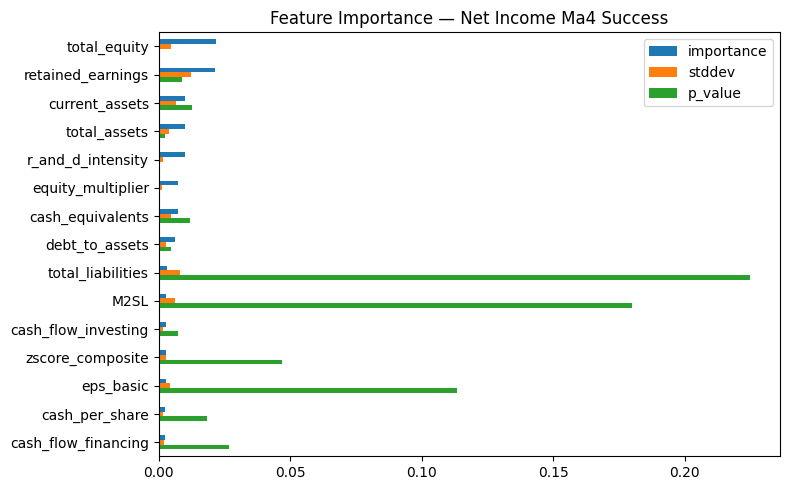

In [190]:
fi = predictor.feature_importance(test_df)
fi = fi.drop(columns=["n","p99_high","p99_low"])
print(fi.head(15))
fi.head(15).plot.barh(figsize=(8, 5), title="Feature Importance")
plt.gca().invert_yaxis()               # optional: keep most-important at top
plt.title("Feature Importance — Net Income Ma4 Success")
plt.tight_layout()
plt.show()

Saved ROC curve to /Volumes/VIK_SSD/thesis_work/market_shifts/data/processed/firms/MODEL/logs/roc_curve.png


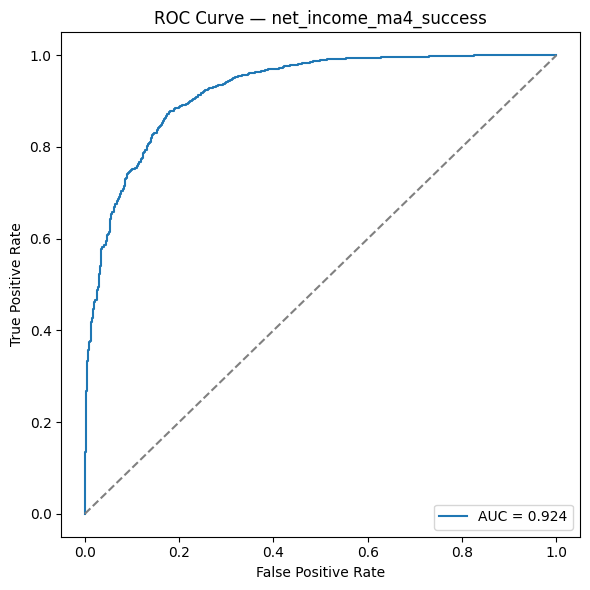

In [191]:
# ─── Robust ROC Curve Cell ───────────────────────────────────────────────
from sklearn.metrics import roc_curve, auc
import matplotlib.pyplot as plt

# 1) Get predicted probabilities as a pandas DataFrame
proba = predictor4.predict_proba(test_df[features], as_pandas=True)

# 2) Identify the positive‐class label (usually 1)
#    AutoGluon stores classes in predictor.class_labels
pos_label = predictor4.class_labels[1] if len(predictor4.class_labels) > 1 else predictor4.class_labels[0]

# 3) Extract the column for that label
if isinstance(proba, pd.DataFrame):
    y_prob = proba[pos_label]
else:
    # fallback if numpy array
    y_prob = proba[:, 1]

# 4) True labels
y_true = test_df[target].values

# 5) Compute ROC
fpr, tpr, _ = roc_curve(y_true, y_prob)
roc_auc = auc(fpr, tpr)

# 6) Plot
plt.figure(figsize=(6,6))
plt.plot(fpr, tpr, label=f"AUC = {roc_auc:.3f}")
plt.plot([0,1], [0,1], "--", color="gray")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title(f"ROC Curve — {target}")
plt.legend(loc="lower right")
plt.tight_layout()

# 7) Save
out_fp = Path(predictor4.path) / "roc_curve.png"
plt.savefig(out_fp, dpi=150)
print(f"Saved ROC curve to {out_fp}")

# 8) Display
plt.show()


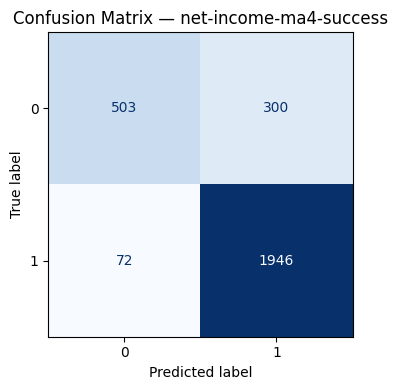

In [192]:
# ─── Confusion Matrix ────────────────────────────────────────────────
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

y_pred = predictor4.predict(test_df[features])
cm = confusion_matrix(y_true, y_pred, labels=predictor4.class_labels)
disp = ConfusionMatrixDisplay(cm, display_labels=predictor4.class_labels)
fig, ax = plt.subplots(figsize=(4,4))
disp.plot(ax=ax, cmap="Blues", colorbar=False)
plt.title("Confusion Matrix — net-income-ma4-success")
plt.tight_layout()

plt.show()
